# Focal Loss for Lens Finding

Implement Focal Loss to improve upon the baseline AUC and PR-AUC metrics by down-weighting easy examples and focusing on hard negatives.

In [7]:
# Fix tqdm for notebooks
import tqdm
import tqdm.notebook
tqdm.notebook.tqdm = tqdm.tqdm

In [8]:
# Import Required Libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import os
import sys
import json
import glob
import math
from sklearn.metrics import roc_auc_score, average_precision_score
from torch import optim
from transformers import get_cosine_schedule_with_warmup
from tqdm import tqdm

# Add path for Lensing_DomainAdaptation module
sys.path.insert(0, '../Lensing_DomainAdaptation')
from models import Encoder, Classifier
from dataset import prep_data
from utils import Pretraining_HPAMS, set_seed

# Import baseline utilities (dataset wrapper and dataloaders)
sys.path.insert(0, '../src')
from baseline_utils import LensDataset, create_dataloaders

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
set_seed(42)
print(f"Device: {device}")
print("All imports OK")

Device: cpu
All imports OK


In [9]:
# Implement Focal Loss Function
# Focal Loss: FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
# Designed to handle class imbalance by down-weighting easy examples

class FocalLoss(nn.Module):
    """
    Focal Loss for binary classification with class imbalance.
    Focuses training on hard negatives and reduces weight of easy examples.
    
    Args:
        alpha: Weighting factor in range [0, 1] to balance positive/negative examples
        gamma: Exponent of the modulating factor (1 - p_t)^gamma to balance easy/hard examples
    """
    def __init__(self, alpha=0.25, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
    
    def forward(self, logits, targets):
        """
        Args:
            logits: Raw predictions from model (before sigmoid), shape [batch_size, 1]
            targets: Ground truth labels, shape [batch_size, 1]
        
        Returns:
            Scalar focal loss value
        """
        # Compute sigmoid probabilities
        probs = torch.sigmoid(logits)
        
        # Compute focal loss
        # CE_loss = -[y * log(p) + (1-y) * log(1-p)]
        ce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        
        # Focal loss = -alpha * (1 - p_t)^gamma * CE_loss
        # where p_t = p if y=1, else (1-p)
        p_t = torch.where(targets == 1, probs, 1 - probs)
        focal_weight = (1 - p_t) ** self.gamma
        focal_loss = self.alpha * focal_weight * ce_loss
        
        return focal_loss.mean()

In [10]:
from sklearn.model_selection import train_test_split
import numpy as np

BASE_DIR = '../lens-finding-test'
TRAIN_LENS = f'{BASE_DIR}/train_lenses'
TRAIN_NONLENS = f'{BASE_DIR}/train_nonlenses'

cls_lens = [TRAIN_LENS + '/' + f for f in os.listdir(TRAIN_LENS) if f.endswith('.npy')]
cls_nonlens = [TRAIN_NONLENS + '/' + f for f in os.listdir(TRAIN_NONLENS) if f.endswith('.npy')]

# 90:10 split
lens_train, lens_val = train_test_split(cls_lens, test_size=0.10, random_state=42)
nonlens_train, nonlens_val = train_test_split(cls_nonlens, test_size=0.10, random_state=42)

def make_labeled(paths, label):
    return np.array([[p, str(label)] for p in paths])

X_train = np.concatenate([make_labeled(nonlens_train, 0), make_labeled(lens_train, 1)])
X_test = np.concatenate([make_labeled(nonlens_val, 0), make_labeled(lens_val, 1)])

print(f"Train lenses: {len(cls_lens)}, Train non-lenses: {len(cls_nonlens)}")
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

train_loader, test_loader = create_dataloaders(
    X_train, X_test,
    batch_size_train=64,
    batch_size_test=100
)

print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")

Train lenses: 1730, Train non-lenses: 28675
Train: (27364, 2), Test: (3041, 2)
Train batches: 427, Test batches: 31


In [11]:
# Initialize Encoder and Classifier Models
encoder = Encoder(model_name='tf_efficientnet_b2_ns', pretrained=False).to(device)
classifier = Classifier().to(device)

# **LOAD BASELINE TRAINED WEIGHTS** to fine-tune with focal loss
baseline_encoder_files = glob.glob('../results/ Encoder_val_auc *.pth')
baseline_classifier_files = glob.glob('../results/ Classiifier_val_auc *.pth')

if baseline_encoder_files and baseline_classifier_files:
    # Get the latest baseline model (highest validation AUC from baseline training)
    baseline_encoder_path = sorted(baseline_encoder_files)[-1]
    baseline_classifier_path = sorted(baseline_classifier_files)[-1]
    
    print(f"Loading baseline encoder: {baseline_encoder_path}")
    print(f"Loading baseline classifier: {baseline_classifier_path}")
    
    encoder.load_state_dict(torch.load(baseline_encoder_path, map_location=device))
    classifier.load_state_dict(torch.load(baseline_classifier_path, map_location=device))
    print("✓ Baseline weights loaded successfully!")
else:
    print("WARNING: No baseline weights found. Starting from random initialization.")
    print("Make sure baseline notebook has completed training first.")

# Initialize hyperparameters for fine-tuning
hpms = Pretraining_HPAMS()
hpms.pretraining_epochs = 3
print("Model initialized with baseline weights")
print(f"Hyperparameters: {hpms.__dict__}")

/home/ojbaby/pytorch_env/lib/python3.12/site-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name tf_efficientnet_b2_ns to current tf_efficientnet_b2.ns_jft_in1k.
  model = create_fn(


Loading baseline encoder: ../results/ Encoder_val_auc nan.pth
Loading baseline classifier: ../results/ Classiifier_val_auc nan.pth
✓ Baseline weights loaded successfully!
Model initialized with baseline weights
Hyperparameters: {'pretraining_epochs': 3, 'pretraining_warmup_epochs': 3, 'pretraining_learning_rate': 0.0001, 'pretraining_weight_decay': 1e-05}


In [12]:
# Fine-tune Baseline with Focal Loss
# Starting from baseline trained weights, we fine-tune with focal loss to improve metrics

OUTPUT_DIR = '../results/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Initialize optimizer and scheduler
criterion = FocalLoss(alpha=0.25, gamma=2.0)

# Use slightly lower learning rate for fine-tuning (we're already at a good baseline)
fine_tune_lr = hpms.pretraining_learning_rate * 0.5

optimizer = optim.AdamW(
    list(encoder.parameters()) + list(classifier.parameters()),
    lr=fine_tune_lr,
    weight_decay=hpms.pretraining_weight_decay
)

epochs = hpms.pretraining_epochs
warmup_epochs = hpms.pretraining_warmup_epochs

num_train_steps = math.ceil(len(train_loader))
num_warmup_steps = num_train_steps * warmup_epochs
num_training_steps = int(num_train_steps * epochs)
scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps
)

# Fine-tuning loop
train_losses = []
val_aucs = []
val_losses = []

print("Starting fine-tuning with Focal Loss...")
print(f"Learning rate: {fine_tune_lr} (reduced for fine-tuning from baseline)")

for epoch in range(epochs):
    # Train epoch
    encoder.train()
    classifier.train()
    epoch_loss = 0.0
    
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Fine-tune]")
    for images, labels in loop:
        images = images.to(device)
        labels = labels.unsqueeze(1).float().to(device)
        
        # Forward pass
        features = encoder(images)
        logits = classifier(features)
        
        # Focal loss computation
        loss = criterion(logits, labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()
        
        epoch_loss += loss.item()
        loop.set_postfix(loss=loss.item())
    
    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Validation epoch
    encoder.eval()
    classifier.eval()
    val_loss = 0.0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        loop = tqdm(test_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]")
        for images, labels in loop:
            images = images.to(device)
            labels = labels.unsqueeze(1).float().to(device)
            
            features = encoder(images)
            logits = classifier(features)
            loss = criterion(logits, labels)
            
            val_loss += loss.item()
            
            probs = torch.sigmoid(logits).cpu().numpy()
            all_preds.extend(probs.flatten())
            all_targets.extend(labels.cpu().numpy().flatten())
            
            loop.set_postfix(loss=loss.item())
    
    avg_val_loss = val_loss / len(test_loader)
    val_auc = roc_auc_score(all_targets, all_preds)
    val_losses.append(avg_val_loss)
    val_aucs.append(val_auc)
    
    print(f"\nEpoch {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Val AUC: {val_auc:.4f}\n")
    
    # Save checkpoint
    torch.save(encoder.state_dict(), OUTPUT_DIR + f'FocalLoss_Encoder_epoch{epoch+1}_auc{val_auc:.4f}.pth')
    torch.save(classifier.state_dict(), OUTPUT_DIR + f'FocalLoss_Classifier_epoch{epoch+1}_auc{val_auc:.4f}.pth')

print("Fine-tuning completed!")

Starting fine-tuning with Focal Loss...
Learning rate: 5e-05 (reduced for fine-tuning from baseline)


Epoch 1/3 [Val]: 100%|██████████| 31/31 [00:19<00:00,  1.56it/s, loss=0.171]   



Epoch 1/3 - Train Loss: 0.0088, Val Loss: 0.0150, Val AUC: 0.9166



Epoch 2/3 [Val]: 100%|██████████| 31/31 [00:18<00:00,  1.70it/s, loss=0.178]   



Epoch 2/3 - Train Loss: 0.0060, Val Loss: 0.0151, Val AUC: 0.9136



Epoch 3/3 [Val]: 100%|██████████| 31/31 [00:18<00:00,  1.69it/s, loss=0.187]   


Epoch 3/3 - Train Loss: 0.0043, Val Loss: 0.0158, Val AUC: 0.9154

Fine-tuning completed!


Loading: ../results/FocalLoss_Encoder_epoch3_auc0.9154.pth


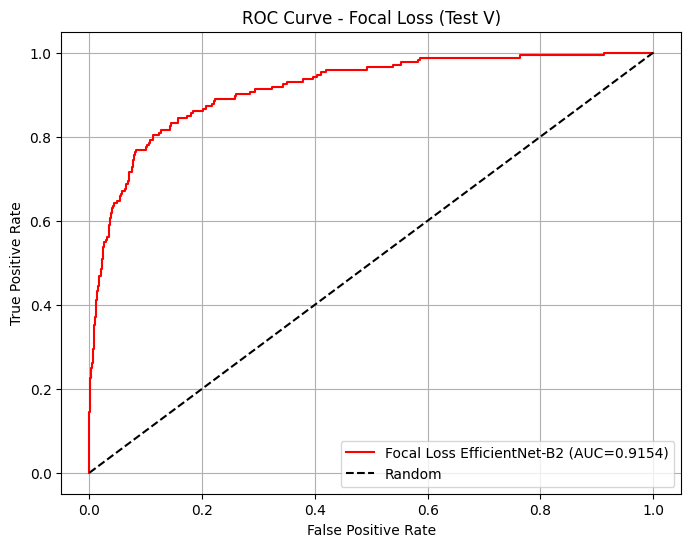

ROC curve saved to results/roc_curve_focal_loss.png

FOCAL LOSS EVALUATION RESULTS
AUCROC: 0.9154
PR-AUC: 0.5762

COMPARISON: FOCAL LOSS vs BASELINE
Baseline AUCROC: 0.9104 -> Focal Loss: 0.9154 (Improvement: +0.0050)
Baseline PR-AUC: 0.5500 -> Focal Loss: 0.5762 (Improvement: +0.0262)


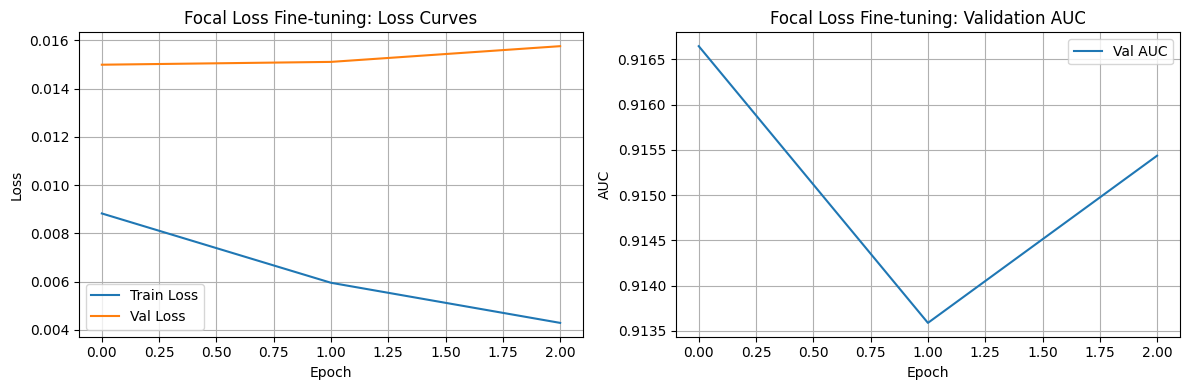


All results saved to results/


In [20]:
# Evaluate Fine-tuned Focal Loss and Compare with Baseline
from sklearn.metrics import roc_curve
import csv
import pandas as pd
import matplotlib.pyplot as plt

focal_encoder_files = glob.glob('../results/FocalLoss_Encoder_*.pth')
best_focal_encoder = max(focal_encoder_files, key=os.path.getctime)
best_focal_classifier = best_focal_encoder.replace('Encoder', 'Classifier')

print(f"Loading: {best_focal_encoder}")
encoder.load_state_dict(torch.load(best_focal_encoder, map_location=device))
classifier.load_state_dict(torch.load(best_focal_classifier, map_location=device))

encoder.eval()
classifier.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        features = encoder(images)
        logits = classifier(features)
        predictions = torch.sigmoid(logits).cpu().numpy()
        all_predictions.extend(predictions.flatten())
        all_labels.extend(labels.numpy())

all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)

focal_aucroc = roc_auc_score(all_labels, all_predictions)
focal_prauc = average_precision_score(all_labels, all_predictions)

# ROC curve for focal loss
fpr, tpr, _ = roc_curve(all_labels, all_predictions)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='red', label=f'Focal Loss EfficientNet-B2 (AUC={focal_aucroc:.4f})')
plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Focal Loss (Test V)')
plt.legend()
plt.grid()
plt.savefig('../results/roc_curve_focal_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print("ROC curve saved to results/roc_curve_focal_loss.png")

metrics_focal = {
    "model": "EfficientNet_B2_finetuned_focal_loss",
    "aucroc": round(focal_aucroc, 4),
    "pr_auc": round(focal_prauc, 4)
}

with open('../results/focal_loss_metrics.json', 'w') as f:
    json.dump(metrics_focal, f, indent=2)

with open('../results/baseline(TestV)_metrics/baseline_metrics.json', 'r') as f:
    baseline_metrics = json.load(f)

aucroc_improvement = focal_aucroc - baseline_metrics['aucroc']
prauc_improvement = focal_prauc - baseline_metrics['pr_auc']

print(f"\nFOCAL LOSS EVALUATION RESULTS")
print(f"AUCROC: {focal_aucroc:.4f}")
print(f"PR-AUC: {focal_prauc:.4f}")
print(f"\nCOMPARISON: FOCAL LOSS vs BASELINE")
print(f"Baseline AUCROC: {baseline_metrics['aucroc']:.4f} -> Focal Loss: {focal_aucroc:.4f} (Improvement: {aucroc_improvement:+.4f})")
print(f"Baseline PR-AUC: {baseline_metrics['pr_auc']:.4f} -> Focal Loss: {focal_prauc:.4f} (Improvement: {prauc_improvement:+.4f})")

comparison_data = [
    ["Metric", "Baseline", "Focal Loss", "Difference"],
    ["AUCROC", baseline_metrics['aucroc'], focal_aucroc, aucroc_improvement],
    ["PR-AUC", baseline_metrics['pr_auc'], focal_prauc, prauc_improvement]
]

with open('../results/focal_loss_comparison.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerows(comparison_data)

loss_data = pd.DataFrame({
    'epoch': range(1, len(train_losses) + 1),
    'train_loss': train_losses,
    'val_loss': val_losses,
    'val_auc': val_aucs
})
loss_data.to_csv('../results/focal_loss_training_curves.csv', index=False)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Focal Loss Fine-tuning: Loss Curves')
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(val_aucs, label='Val AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()
plt.title('Focal Loss Fine-tuning: Validation AUC')
plt.grid()

plt.tight_layout()
plt.savefig('../results/focal_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'='*40}")
print(f"All results saved to results/")
print(f"{'='*40}")